In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# ── Cell 1: Install dependencies
!pip install pydicom kagglehub scikit-image matplotlib opencv-python-headless seaborn -q

In [ ]:
# ── Cell 2: Download dataset
import kagglehub
path = kagglehub.dataset_download("anhoangvo/chaos-t1-and-t2")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chaos-t1-and-t2' dataset.
Path to dataset files: /kaggle/input/chaos-t1-and-t2


In [ ]:
# ── Cell 3: Explore folder structure
import os
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level > 3: continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files[:2]:
        print(f'{indent}  └─ {f}')

chaos-t1-and-t2/
  chaos/
    t1/
      19/
        └─ patient19_t1_outphase_5.npz
        └─ patient19_t1_inphase_17.npz
      22/
        └─ patient22_t1_inphase_33.npz
        └─ patient22_t1_inphase_28.npz
      2/
        └─ patient2_t1_inphase_5.npz
        └─ patient2_t1_outphase_6.npz
      10/
        └─ patient10_t1_inphase_8.npz
        └─ patient10_t1_outphase_3.npz
      5/
        └─ patient5_t1_outphase_1.npz
        └─ patient5_t1_inphase_14.npz
      36/
        └─ patient36_t1_outphase_12.npz
        └─ patient36_t1_outphase_22.npz
      20/
        └─ patient20_t1_inphase_12.npz
        └─ patient20_t1_inphase_5.npz
      39/
        └─ patient39_t1_inphase_24.npz
        └─ patient39_t1_outphase_13.npz
      32/
        └─ patient32_t1_inphase_3.npz
        └─ patient32_t1_inphase_16.npz
      8/
        └─ patient8_t1_outphase_16.npz
        └─ patient8_t1_inphase_20.npz
      38/
        └─ patient38_t1_outphase_4.npz
        └─ patient38_t1_inphase_33.npz
      3

In [ ]:
# ── Cell 4: Load one patient's slices → 3D volume
import numpy as np
import os
import re

def load_patient_volume(patient_folder):
    slices_with_info = []
    for f in sorted(os.listdir(patient_folder)):
        if f.endswith(".npz"):
            filepath = os.path.join(patient_folder, f)
            try:
                data = np.load(filepath, allow_pickle=True)
                # If the data is a scalar (like a string), it's not the pixel array
                # We check all keys for an actual image array
                slice_data = None
                for key in data.keys():
                    val = data[key]
                    if isinstance(val, np.ndarray) and val.ndim >= 2:
                        slice_data = val
                        break

                if slice_data is None:
                    continue

                match = re.search(r'(\d+)\.npz$', f)
                slice_num = int(match.group(1)) if match else 0
                slices_with_info.append((slice_data, slice_num))
            except Exception as e:
                print(f"Error loading {f}: {e}")
                continue

    if not slices_with_info:
        print("No pixel arrays found in .npz files. Checking for alternative keys...")
        raise ValueError("Could not find 2D image arrays in the provided .npz files.")

    slices_with_info.sort(key=lambda x: x[1])
    volume = np.stack([s[0] for s in slices_with_info], axis=0)
    print(f"Loaded volume shape: {volume.shape}")
    return volume

patient_path = os.path.join(path, "chaos", "t2", "2")
try:
    volume_3d = load_patient_volume(patient_path)
except Exception as e:
    print(f"Final Error: {e}")

Loaded volume shape: (26, 256, 256)


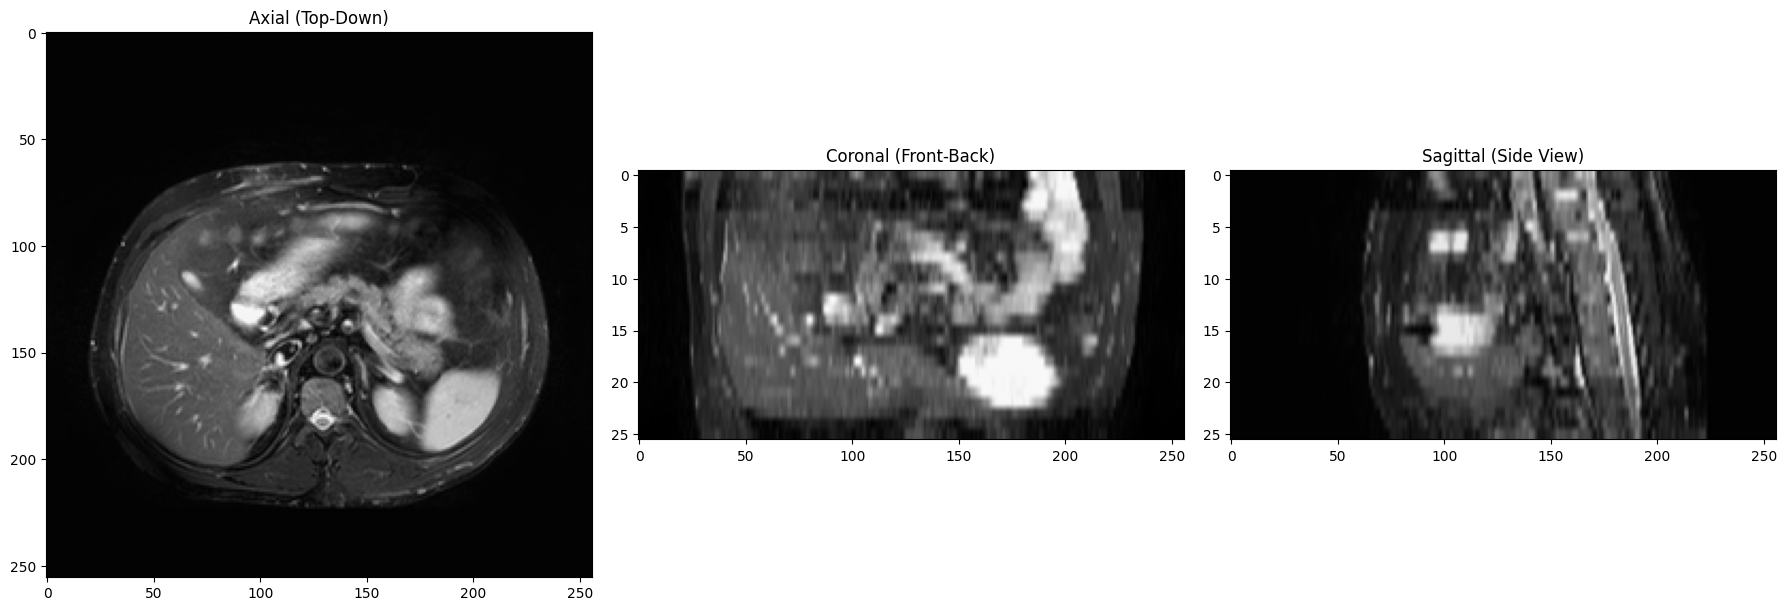

In [ ]:
import matplotlib.pyplot as plt

def show_three_planes(volume, slice_thickness=7.84, pixel_spacing=1.61):
    mid_z = volume.shape[0] // 2
    mid_y = volume.shape[1] // 2
    mid_x = volume.shape[2] // 2

    aspect_ratio = slice_thickness / pixel_spacing

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(volume[mid_z, :, :], cmap='gray', aspect='equal')
    axes[0].set_title('Axial (Top-Down)')

    axes[1].imshow(volume[:, mid_y, :], cmap='gray', aspect=aspect_ratio)
    axes[1].set_title('Coronal (Front-Back)')

    axes[2].imshow(volume[:, :, mid_x], cmap='gray', aspect=aspect_ratio)
    axes[2].set_title('Sagittal (Side View)')

    plt.tight_layout()
    plt.show()

show_three_planes(volume_3d)

In [ ]:
# ── Cell 5b: MPR Slider — Colab-safe image widget approach ─────────────────
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import io

SLICE_THICKNESS = 7.84
PIXEL_SPACING   = 1.61
ASPECT          = SLICE_THICKNESS / PIXEL_SPACING

D, H, W = volume_3d.shape

# ── Sliders
axial_slider = widgets.IntSlider(
    value=D // 2, min=0, max=D - 1, step=1,
    description="🔴 Axial  Z",
    continuous_update=True,
    style={"description_width": "110px"},
    layout=widgets.Layout(width="600px"),
)
coronal_slider = widgets.IntSlider(
    value=H // 2, min=0, max=H - 1, step=1,
    description="🟡 Coronal  Y",
    continuous_update=True,
    style={"description_width": "110px"},
    layout=widgets.Layout(width="600px"),
)
sagittal_slider = widgets.IntSlider(
    value=W // 2, min=0, max=W - 1, step=1,
    description="🔵 Sagittal  X",
    continuous_update=True,
    style={"description_width": "110px"},
    layout=widgets.Layout(width="600px"),
)

# ── Image widget — this is where the plot lives permanently
img_widget = widgets.Image(format='png',
                           layout=widgets.Layout(width='100%'))

# ── Render → PNG bytes → push into img_widget.value
def render(_change=None):
    z = axial_slider.value
    y = coronal_slider.value
    x = sagittal_slider.value

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#111111")
    fig.suptitle(
        f"MPR  —  Axial Z={z}  |  Coronal Y={y}  |  Sagittal X={x}",
        color="white", fontsize=13,
    )

    panels = [
        (volume_3d[z, :, :], "equal",  f"Axial  [Z = {z}]",    "X → Width",  "Y ↓ Height", y,  x,  "yellow", "cyan"),
        (volume_3d[:, y, :], ASPECT,   f"Coronal  [Y = {y}]",  "X → Width",  "Z ↓ Depth",  z,  x,  "red",    "cyan"),
        (volume_3d[:, :, x], ASPECT,   f"Sagittal  [X = {x}]", "Y → Height", "Z ↓ Depth",  z,  y,  "red",    "yellow"),
    ]

    for ax, (img, asp, title, xlabel, ylabel, hline, vline, hcol, vcol) in zip(axes, panels):
        ax.imshow(img, cmap="gray", aspect=asp)
        ax.axhline(hline, color=hcol, linewidth=1.2, alpha=0.85)
        ax.axvline(vline, color=vcol, linewidth=1.2, alpha=0.85)
        ax.set_title(title,  color="white", fontsize=11)
        ax.set_xlabel(xlabel, color="white")
        ax.set_ylabel(ylabel, color="white")
        ax.tick_params(colors="white")
        ax.set_facecolor("#111111")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444444")

    plt.tight_layout()

    # ── Bake figure → PNG bytes → push to widget (no plt.show needed)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight',
                facecolor=fig.get_facecolor())
    buf.seek(0)
    img_widget.value = buf.read()       # widget re-renders automatically
    plt.close(fig)                      # free RAM

# ── Wire sliders
axial_slider.observe   (render, names='value')
coronal_slider.observe (render, names='value')
sagittal_slider.observe(render, names='value')

# ── Display everything, then draw the first frame
display(widgets.VBox([
    axial_slider,
    coronal_slider,
    sagittal_slider,
    img_widget,
]))

render()

In [ ]:
import numpy as np
import scipy.ndimage
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

%matplotlib inline


if 'volume_3d' not in locals():
    print("❌ Error: 'volume_3d' not found. Please run your data loading cell first.")
else:
    # --- The Logic
    def extract_oblique_sample(volume, depth, tilt_deg, swing_deg):
        """
        Extract an oblique slice from a 3D volume using the tilt and swing angles.
        """
        d, h, w = volume.shape
        tilt, swing = np.deg2rad(tilt_deg), np.deg2rad(swing_deg)

        # Create meshgrid to represent the 2D slice
        hi, wi = np.arange(h) - h / 2.0, np.arange(w) - w / 2.0
        grid_h, grid_w = np.meshgrid(hi, wi, indexing='ij')

        # Calculate the offset for each pixel in the slice
        depth_offset = grid_h * np.tan(tilt) + grid_w * np.tan(swing)

        # Clip coordinates to ensure they are within bounds
        coords = [np.clip(depth + depth_offset, 0, d - 1),  # Depth coordinates with offset
                  np.clip(h / 2.0 + grid_h, 0, h - 1),     # Y-coordinates
                  np.clip(w / 2.0 + grid_w, 0, w - 1)]     # X-coordinates

        return scipy.ndimage.map_coordinates(volume, coords, order=1)

    # --- The UI
    out = widgets.Output()

    def on_value_change(change):
        with out:
            clear_output(wait=True)  # Clears the previous plot

            # Extract the oblique slice using the parameters from the sliders
            oblique = extract_oblique_sample(volume_3d, depth_s.value, tilt_s.value, swing_s.value)

            # Plot the extracted oblique slice
            fig, ax = plt.subplots(figsize=(6, 6), facecolor='#111')
            ax.imshow(oblique, cmap='gray')
            ax.axis('on')
            plt.show()

    # Define sliders
    tilt_s = widgets.IntSlider(value=0, min=-45, max=45, description="Tilt")
    swing_s = widgets.IntSlider(value=0, min=-45, max=45, description="Swing")
    depth_s = widgets.IntSlider(value=volume_3d.shape[0] // 2, min=0, max=volume_3d.shape[0] - 1, description="Depth")

    # Link the sliders to the callback function
    for s in [tilt_s, swing_s, depth_s]:
        s.observe(on_value_change, names='value')


    display(widgets.VBox([tilt_s, swing_s, depth_s, out]))

    on_value_change(None)

In [ ]:
import plotly.graph_objects as go
import plotly.io as pio
from skimage import measure
from scipy.ndimage import gaussian_filter

# --- 1. Set Renderer (Fixes blank Plotly screens)
pio.renderers.default = "colab"

# --- 2. Downsample and Process ---
# sigma=1.5 is good for smoothing noise
vol_smooth = gaussian_filter(volume_3d.astype(float), sigma=1.5)

# CRITICAL: step_size=2 or 3 reduces geometry by 8x-27x, allowing it to load
verts, faces, _, _ = measure.marching_cubes(vol_smooth, level=225, step_size=2)

# Scale by physical dimensions
x_vals = verts[:, 2] * PIXEL_SPACING
y_vals = verts[:, 1] * PIXEL_SPACING
z_vals = verts[:, 0] * SLICE_THICKNESS

# --- 3. Render ---
fig = go.Figure(data=[go.Mesh3d(
    x=x_vals, y=y_vals, z=z_vals,
    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
    intensity=z_vals,
    colorscale='Viridis',
    opacity=0.8
)])

fig.update_layout(
    scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_visible=False, aspectmode='data'),
    paper_bgcolor='black',
    margin=dict(l=0, r=0, b=0, t=0)
)
fig.show()